## Simulations

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

def extract_values(file_path):
    """
    Parses a results file to extract values for each method.

    Assumes lines are formatted as: `[ignored] [method_name] [v1,v2,...]`.

    Args:
        file_path (str): The path to the input results file.

    Returns:
        Dict[str, List[float]]: A dictionary mapping method names (e.g., 'GEE')
        to a list of their corresponding floating-point metric values.
    """
    values = {'GEE': [], 'GNN': [], 'GG': [], 'GG2': []}

    with open(file_path, 'r') as file:
        lines = file.readlines()

    for line in lines:
        if line.strip() and not line.startswith('r_value'):
            parts = line.strip().split()
            method = parts[1]
            acc_values = list(map(float, parts[2].split(',')))

            values[method].extend(acc_values)

    return values

def mean_stderr(x: np.ndarray, block: int):
    """
    Computes mean and standard error for non-overlapping data blocks.
    
    Args:
        x (np.ndarray): A 1D array of data points.
        block_size (int): The size of each block to average over.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
            - An array of the means calculated for each block.
            - An array of the standard errors of the mean for each block.

    """
    x = np.asarray(x)[: (len(x) // block) * block]      
    x = x.reshape(-1, block)                           
    mean   = x.mean(axis=1)
    stderr = x.std(axis=1, ddof=1) / np.sqrt(block)
    return mean, stderr



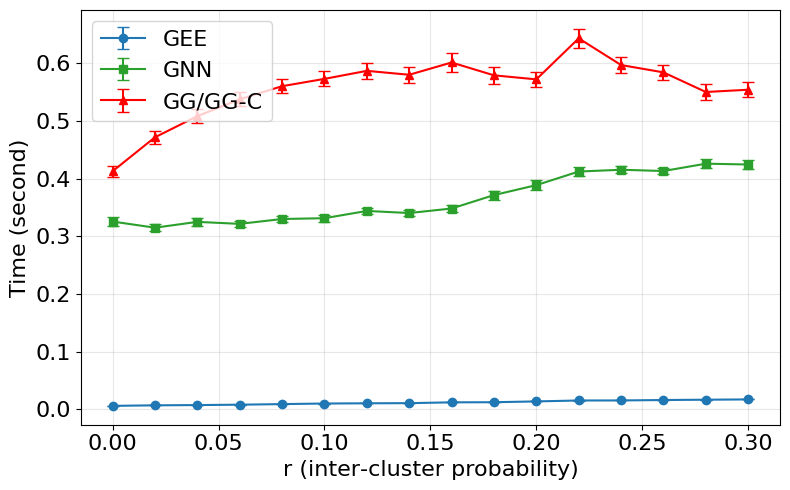

In [17]:
plt.rcParams.update({
    "figure.titlesize": 18,     
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16
})

flag = "DC_SBM" # "SBM"
content = "time"
unbal = "unbal"
num_folds = 2
percent = int(100 / num_folds)
File   = Path(f"results/{flag}/{percent}%/{content}_{unbal}.txt")
fig_path = f"results/{flag}/{percent}%/{flag}_{content}_{percent}.png"
BLOCK  = 200                     
r_vals =  np.arange(0, 0.151, 0.01) if flag == "SBM" else np.arange(0, 0.305, 0.02) 
# r_vals = np.array([0.15])
title = "Accuracy" if content == "acc" else "Time"
ylabel = f"{percent}% Train/Val Set" if content == "acc" else "Time (second)"
if content == "acc":
    methods = ("GEE", "GNN", "GG", "GG2")
    markers = dict(GEE="o", GNN="s", GG="^", GG2=">")
    colors  = dict(GEE="#1f77b4", GNN="#2ca02c", GG="red",GG2="#e60073")
else:
    methods = ("GEE", "GNN", "GG")
    markers = dict(GEE="o", GNN="s", GG="^")
    colors  = dict(GEE="#1f77b4", GNN="#2ca02c", GG="red")

# ---------------- Plot ----------------
vals = extract_values(File)                       
plt.figure(figsize=(8, 5))
for m in methods:
    mean, err = mean_stderr(vals[m], BLOCK)
    label = m
    if m == "GG2":
        label = "GG-C"
    if m == "GG" and content == "time":
        label = m + "/GG-C"
    plt.errorbar(r_vals, mean, yerr=err,
                    fmt=f'-{markers[m]}', color=colors[m],
                    capsize=4, label=label)

plt.xlabel("r (inter‑cluster probability)")
plt.ylabel(ylabel)
# plt.title(f"Comparison of {title} on {flag}", fontweight="bold")
plt.grid(alpha=.3)
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

## Real data

In [49]:
from rich.table import Table
from io import StringIO
from rich.console import Console
def extract_values_realdata(file_path):
    """
    Parses a results file to compute mean and standard error per dataset.

    Args:
        file_path (str): The path to the input results file.

    Returns:
        Dict[str, Dict[str, Tuple[float, float]]]: A nested dictionary with the
        structure: `{dataset: {method: (mean, standard_error)}}`.
    """
    
    values = {}

    with open(file_path, 'r') as file:
        lines = file.readlines()

    for line in lines:
        if line.strip() and not line.startswith('r_value'):
            parts = line.strip().split()
            dataset = parts[0]
            method = parts[1]
            acc_values = list(map(float, parts[2].split(',')))
            if dataset not in values:
                values[dataset] = {}
            values[dataset][method] = (np.mean(acc_values),  np.std(acc_values, ddof=1)/np.sqrt(len(acc_values)) )

    return values

def draw_one(df_slice, filename, title, ylabel):
    fig, ax = plt.subplots(figsize=(8, 5))       
    bar_width = 0.2
    x = np.arange(len(df_slice))
    palette = ["#1f77b4", "#2ca02c", "red", "#e60073"]

    for i, m in enumerate(methods):
        label = m
        if m == "GG2":
            label = "GG-C"
        ax.bar(x + i*bar_width,
               df_slice[m].values,
               bar_width,
               label=label,
               color=palette[i],
               alpha=0.9)

    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(df_slice.index, rotation=45, ha="right")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)   
    plt.show()

#### Acc Tables

In [50]:
Pro = 5
File   = Path(f"results/real_data/{Pro}%/acc.txt")
values = extract_values_realdata(File)

datasets = sorted(values.keys())
methods = ["GEE", "GNN", "GG", "GG2"]
no_gee  = [m for m in methods if m != "GEE"] 

        
console = Console(record=True, width=100)
table = Table(show_lines=True)

table.add_column("Dataset")
for method in methods:
    if method == "GG2":
        method = "GG-C"
    table.add_column(method)

for ds in values:
    row = [ds]
    sorted_m = sorted(
        methods,
        key=lambda m: values[ds][m][0]      
    )
    first  = sorted_m[3]                  
    second = sorted_m[2] 

    for m in methods:
        mean, std = values[ds][m]
        content = f"{mean:.3f} ± {std:.3f}"
        if m == first:         
            content = f"[green]{content}[/green]"
        elif m == second:   
            content = f"[red]{content}[/red]"

        row.append(content)
    
    table.add_row(*row)

console.print(table)



┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Dataset      ┃ GEE           ┃ GNN           ┃ GG            ┃ GG-C          ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ACM          │ 0.469 ± 0.002 │ 0.427 ± 0.004 │ 0.492 ± 0.005 │ 0.534 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ BAT          │ 0.412 ± 0.006 │ 0.294 ± 0.005 │ 0.382 ± 0.007 │ 0.425 ± 0.008 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ DBLP         │ 0.316 ± 0.001 │ 0.297 ± 0.002 │ 0.329 ± 0.002 │ 0.336 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ EAT          │ 0.364 ± 0.005 │ 0.321 ± 0.005 │ 0.351 ± 0.005 │ 0.370 ± 0.005 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ UAT          │ 0.415 ± 0.005 │ 0.358 ± 0.005 │ 0.404 ± 0.006 │ 0.435 ± 0.004 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ Wiki         │ 0.244 ± 0.004 │ 0.224 ± 0.003 │ 0.326 ± 0.003 │ 0.304 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ Gene         │ 0.575 ± 0.004 │ 0.525 ± 0.006 │ 0.531 ± 0.005 │ 0.549 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ IIP          │ 0.410 ± 0.014 │ 0.515 ± 0.008 │ 0.510 ± 0.010 │ 0.444 ± 0.010 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ lastfm       │ 0.333 ± 0.004 │ 0.431 ± 0.003 │ 0.536 ± 0.003 │ 0.509 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ polblogs     │ 0.723 ± 0.005 │ 0.706 ± 0.009 │ 0.729 ± 0.014 │ 0.815 ± 0.009 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ TerroristRel │ 0.737 ± 0.010 │ 0.683 ± 0.006 │ 0.718 ± 0.011 │ 0.765 ± 0.006 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ KarateClub   │ 0.648 ± 0.016 │ 0.257 ± 0.012 │ 0.663 ± 0.019 │ 0.729 ± 0.014 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ Chameleon    │ 0.267 ± 0.004 │ 0.288 ± 0.003 │ 0.270 ± 0.004 │ 0.333 ± 0.003 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ Cora         │ 0.349 ± 0.006 │ 0.318 ± 0.006 │ 0.393 ± 0.005 │ 0.426 ± 0.004 │
├──────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ Citeseer     │ 0.244 ± 0.002 │ 0.238 ± 0.003 │ 0.280 ± 0.003 │ 0.303 ± 0.003 │
└──────────────┴───────────────┴───────────────┴───────────────┴───────────────┘

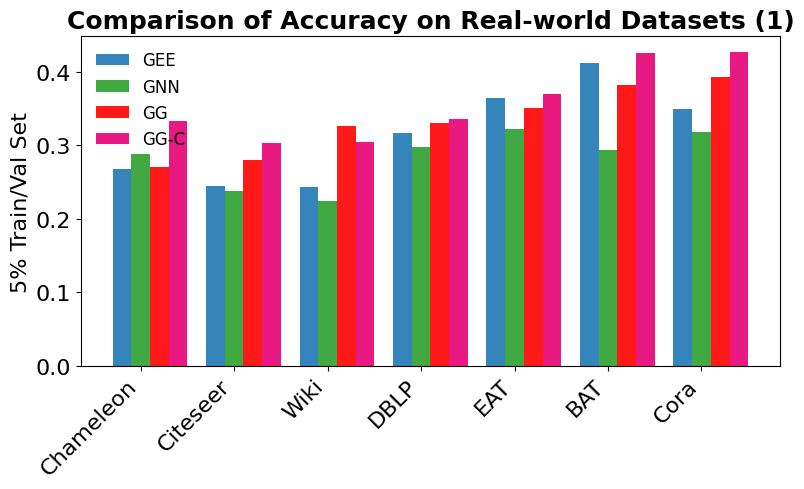

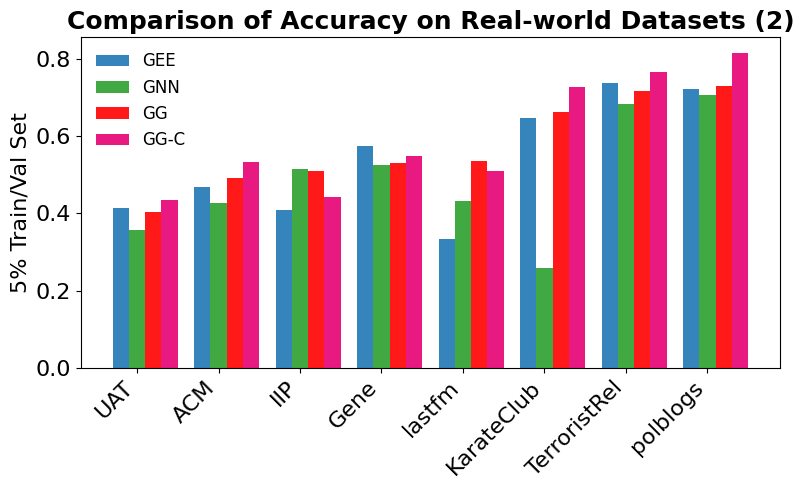

In [51]:
plt.rcParams.update({
    "figure.titlesize": 18,     
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "legend.title_fontsize": 16
})

records = []
for ds in values:                    
    for m in methods:                 
        mu, sigma = values[ds][m]
        records.append({"Dataset": ds, "Method": m, "Mean": mu})

df = pd.DataFrame(records)


gg_sorted = (df[df["Method"] == "GG"]
             .sort_values("Mean")["Dataset"]
             .tolist())


mean_df = (df.pivot(index="Dataset", columns="Method", values="Mean")
             .loc[gg_sorted])

mid = len(mean_df) // 2
first_half  = mean_df.iloc[:mid]
second_half = mean_df.iloc[mid:]

draw_one(first_half,
         f"results/real_data/{Pro}%/acc_errbar1.png",
         "Comparison of Accuracy on Real‑world Datasets (1)",
         f"{Pro}% Train/Val Set")

draw_one(second_half,
         f"results/real_data/{Pro}%/acc_errbar2.png",
         "Comparison of Accuracy on Real‑world Datasets (2)",
         f"{Pro}% Train/Val Set")


#### Time Tables

In [76]:
Pro = 20
File   = Path(f"results/real_data/{Pro}%/time.txt")
# fig_path = f"real_data/{num_folds}fold.png"
values = extract_values_realdata(File)

datasets = sorted(values.keys())
methods = ["GEE", "GNN", "GG", "GG2"]
no_gee  = [m for m in methods if m != "GEE"] 

        
console = Console(record=True, width=100)
table = Table(show_lines=True)

table.add_column("Dataset")
for method in methods:
    if method == "GG2":
        method = "GG-C"
    table.add_column(method)

for ds in values:
    row = [ds]
    sorted_m = sorted(
        no_gee,
        key=lambda m: values[ds][m][0]       
    )
    first  = sorted_m[0]               
    second = sorted_m[1]  

    for m in methods:
        mean, std = values[ds][m]
        content = f"{mean:.2f} ± {std:.2f}"
        if m == first:         
            content = f"[green]{content}[/green]"

        row.append(content)
    
    table.add_row(*row)

console.print(table)


┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Dataset      ┃ GEE         ┃ GNN         ┃ GG          ┃ GG-C        ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ ACM          │ 0.01 ± 0.00 │ 0.39 ± 0.01 │ 0.59 ± 0.03 │ 0.59 ± 0.03 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ BAT          │ 0.00 ± 0.00 │ 0.13 ± 0.00 │ 0.13 ± 0.00 │ 0.13 ± 0.00 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ DBLP         │ 0.00 ± 0.00 │ 0.32 ± 0.01 │ 0.43 ± 0.02 │ 0.43 ± 0.02 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ EAT          │ 0.00 ± 0.00 │ 0.23 ± 0.01 │ 0.22 ± 0.01 │ 0.22 ± 0.01 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ UAT          │ 0.01 ± 0.00 │ 0.40 ± 0.01 │ 0.44 ± 0.02 │ 0.44 ± 0.02 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Wiki         │ 0.01 ± 0.00 │ 0.85 ± 0.03 │ 0.91 ± 0.02 │ 0.91 ± 0.02 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Gene         │ 0.00 ± 0.00 │ 0.20 ± 0.01 │ 0.16 ± 0.01 │ 0.16 ± 0.01 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ IIP          │ 0.00 ± 0.00 │ 0.13 ± 0.00 │ 0.13 ± 0.00 │ 0.13 ± 0.00 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ lastfm       │ 0.02 ± 0.00 │ 1.77 ± 0.06 │ 2.48 ± 0.06 │ 2.48 ± 0.06 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ polblogs     │ 0.01 ± 0.00 │ 0.41 ± 0.01 │ 0.39 ± 0.02 │ 0.39 ± 0.02 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ TerroristRel │ 0.00 ± 0.00 │ 0.29 ± 0.01 │ 0.30 ± 0.01 │ 0.30 ± 0.01 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ KarateClub   │ 0.00 ± 0.00 │ 0.12 ± 0.00 │ 0.12 ± 0.00 │ 0.12 ± 0.00 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Chameleon    │ 0.02 ± 0.00 │ 0.64 ± 0.02 │ 0.70 ± 0.03 │ 0.70 ± 0.03 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Cora         │ 0.00 ± 0.00 │ 0.42 ± 0.01 │ 0.66 ± 0.02 │ 0.66 ± 0.02 │
├──────────────┼─────────────┼─────────────┼─────────────┼─────────────┤
│ Citeseer     │ 0.00 ± 0.00 │ 0.39 ± 0.01 │ 0.65 ± 0.02 │ 0.65 ± 0.02 │
└──────────────┴─────────────┴─────────────┴─────────────┴─────────────┘